In [1]:
import pandas as pd

# We are telling Python: "Go into the data folder and read that giant file"
df = pd.read_csv('data/healthcare_dataset.csv')

# This shows you the first 5 rows in a clean, professional table
print("Successfully loaded 55,000 rows!")
df.head()


Successfully loaded 55,000 rows!


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [2]:
# 1. Check for Missing Values (NULLs)
print("--- Missing Values Per Column ---")
print(df.isnull().sum())

# 2. Check for Duplicate Records
print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")

# 3. Check Data Types (Are numbers actually treated as numbers?)
print("\n--- Data Types ---")
print(df.dtypes)

--- Missing Values Per Column ---
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Total Duplicate Rows: 534

--- Data Types ---
Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object


In [3]:
# 1. Remove the 534 duplicates
df = df.drop_duplicates()
print(f"Cleaned! Remaining rows: {len(df)}")

# 2. Fix the Column Names (Removing spaces makes coding easier)
df.columns = df.columns.str.replace(' ', '_').str.lower()

# 3. Convert Dates from 'Text' to 'Datetime' objects
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# 4. Create the most important feature for Medical AI: Length of Stay
df['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

# 5. Check for 'Negative' stay durations (Data errors)
errors = df[df['length_of_stay'] < 0].shape[0]
print(f"Found {errors} patients with discharge dates before admission dates.")

# Remove those errors if they exist
df = df[df['length_of_stay'] >= 0]

# See your new column
df[['date_of_admission', 'discharge_date', 'length_of_stay']].head()

Cleaned! Remaining rows: 54966
Found 0 patients with discharge dates before admission dates.


,date_of_admission,discharge_date,length_of_stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


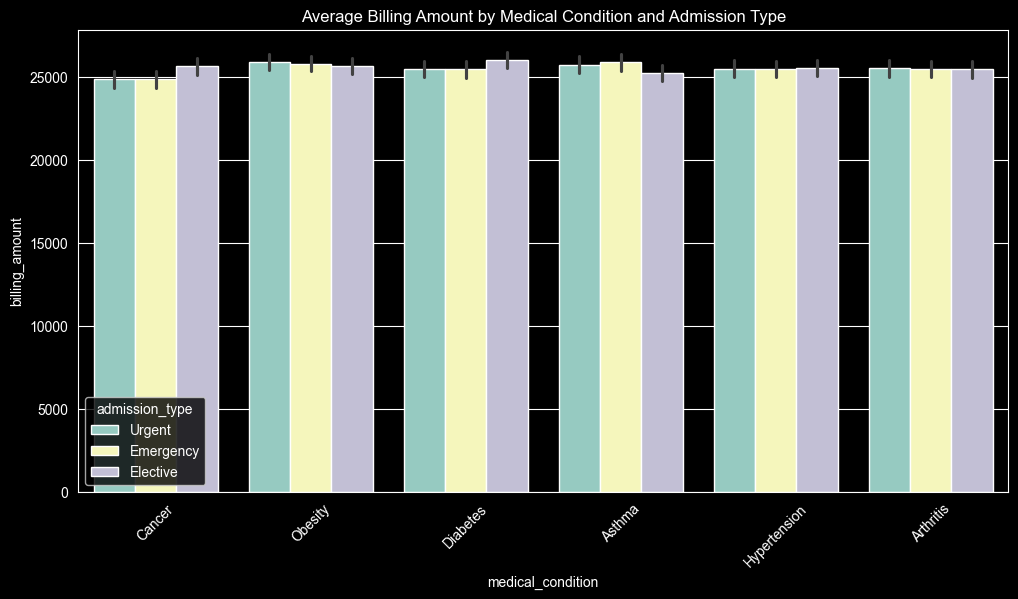

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='medical_condition', y='billing_amount', hue='admission_type')
plt.title('Average Billing Amount by Medical Condition and Admission Type')
plt.xticks(rotation=45)
plt.show()

Created missing folder: ../outputs
Success! Chart saved to: /outputs/billing_analysis.png


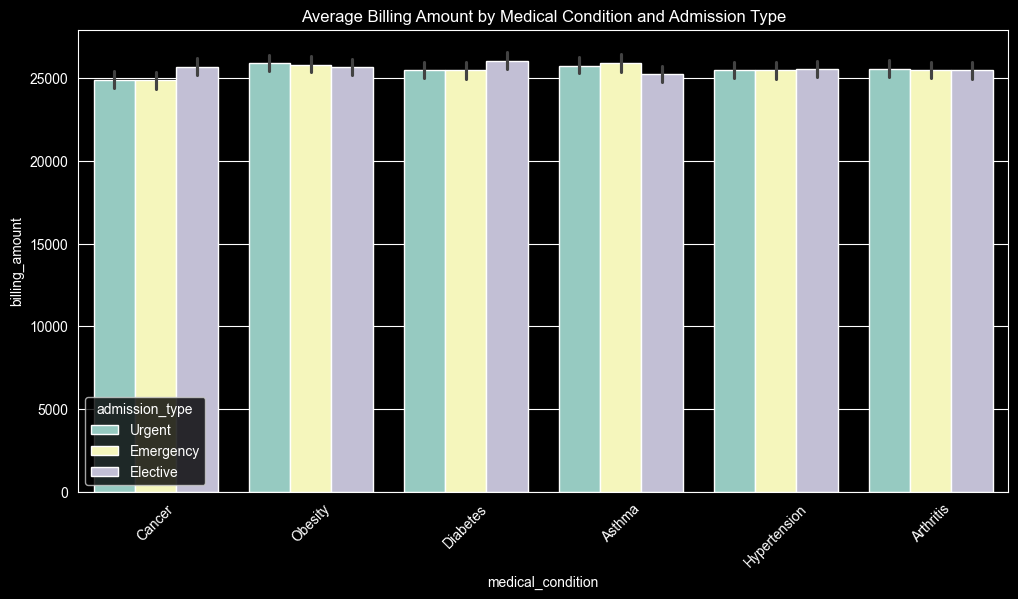

In [8]:
import os
import matplotlib.pyplot as plt

# 1. Create the path to the folder
output_folder = '../outputs'

# 2. Check if the folder exists; if not, create it!
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created missing folder: {output_folder}")

# 3. Now try to save the chart
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='medical_condition', y='billing_amount', hue='admission_type')
plt.title('Average Billing Amount by Medical Condition and Admission Type')
plt.xticks(rotation=45)

plt.savefig('../outputs/billing_analysis.png', dpi=300, bbox_inches='tight')
print("Success! Chart saved to: /outputs/billing_analysis.png")

In [9]:
import os
print(os.path.abspath('../outputs'))

C:\Users\User\PycharmProjects\outputs
